In [7]:
import pickle
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run
from neuralhydrology.datasetzoo.basedataset import BaseDataset
from neuralhydrology.datasetzoo.lamah import LamaH
from neuralhydrology.utils.config import Config

In [8]:
# by default we assume that you have at least one CUDA-capable NVIDIA GPU
if torch.cuda.is_available():
    start_run(config_file=Path("1_basin_lamah.yml"))

# fall back to CPU-only mode
else:
    start_run(config_file=Path("1_basin_lamah.yml"), gpu=-1)

2024-03-26 15:02:35,965: Logging to /home/sngrjohn/GitHub/neuralhydrology/examples/01-Introduction/runs/test_run_lamah_2603_150235/output.log initialized.
2024-03-26 15:02:35,966: ### Folder structure created at /home/sngrjohn/GitHub/neuralhydrology/examples/01-Introduction/runs/test_run_lamah_2603_150235
2024-03-26 15:02:35,967: ### Run configurations for test_run_lamah
2024-03-26 15:02:35,967: experiment_name: test_run_lamah
2024-03-26 15:02:35,968: train_basin_file: 1_basin_lamah.txt
2024-03-26 15:02:35,969: validation_basin_file: 1_basin_lamah.txt
2024-03-26 15:02:35,969: test_basin_file: 1_basin_lamah.txt
2024-03-26 15:02:35,971: train_start_date: 2009-01-12 00:00:00
2024-03-26 15:02:35,972: train_end_date: 2011-06-16 00:00:00
2024-03-26 15:02:35,974: validation_start_date: 2006-01-12 00:00:00
2024-03-26 15:02:35,975: validation_end_date: 2007-01-12 00:00:00
2024-03-26 15:02:35,976: test_start_date: 2007-01-12 00:00:00
2024-03-26 15:02:35,977: test_end_date: 2008-01-12 00:00:00
20

2024-03-26 15:02:35,993: loss: MSE
2024-03-26 15:02:35,995: learning_rate: {0: 0.01, 30: 0.005, 40: 0.001}
2024-03-26 15:02:35,995: batch_size: 256
2024-03-26 15:02:35,996: epochs: 50
2024-03-26 15:02:35,997: clip_gradient_norm: 1
2024-03-26 15:02:35,997: predict_last_n: 1
2024-03-26 15:02:35,998: seq_length: 365
2024-03-26 15:02:35,998: num_workers: 8
2024-03-26 15:02:35,999: log_interval: 5
2024-03-26 15:02:36,000: log_tensorboard: True
2024-03-26 15:02:36,001: log_n_figures: 1
2024-03-26 15:02:36,002: save_weights_every: 1
2024-03-26 15:02:36,002: dataset: lamah_a
2024-03-26 15:02:36,003: data_dir: ../../data/1_LamaH-CE_daily_hourly
2024-03-26 15:02:36,005: forcings: ['maurer', 'daymet', 'nldas']
2024-03-26 15:02:36,006: dynamic_inputs: ['DOY', '2m_temp_max', '2m_temp_mean', '2m_temp_min', '2m_dp_temp_max', '2m_dp_temp_mean', '2m_dp_temp_min', '10m_wind_u', '10m_wind_v', 'fcst_alb', 'lai_high_veg', 'lai_low_veg', 'swe', 'surf_net_solar_rad_max', 'surf_net_solar_rad_mean', 'surf_net_

### Evaluate run on test set
The run directory that needs to be specified for evaluation is printed in the output log above. Since the folder name is created dynamically (including the date and time of the start of the run) you will need to change the `run_dir` argument according to your local directory name. By default, it will use the same device as during the training process.

In [9]:
run_dir = Path("runs/test_run_lamah_2603_150235")
eval_run(run_dir=run_dir, period="test")

2024-03-26 15:03:27,238: Using the model weights from runs/test_run_lamah_2603_150235/model_epoch050.pt
# Evaluation:   0%|          | 0/1 [00:00<?, ?it/s]

# Evaluation: 100%|██████████| 1/1 [00:00<00:00,  5.69it/s]
2024-03-26 15:03:27,446: Stored metrics at runs/test_run_lamah_2603_150235/test/model_epoch050/test_metrics.csv
2024-03-26 15:03:27,447: Stored results at runs/test_run_lamah_2603_150235/test/model_epoch050/test_results.p


### Load and inspect model predictions
Next, we load the results file and compare the model predictions with observations. The results file is always a pickled dictionary with one key per basin (even for a single basin). The next-lower dictionary level is the temporal resolution of the predictions. In this case, we trained a model only on daily data ('1D'). Within the temporal resolution, the next-lower dictionary level are `xr`(an xarray Dataset that contains observations and predictions), as well as one key for each metric that was specified in the config file.

In [10]:
with open(run_dir / "test" / "model_epoch050" / "test_results.p", "rb") as fp:
    results = pickle.load(fp)
    
results.keys()

dict_keys(['1'])

The data variables in the xarray Dataset are named according to the name of the target variables, with suffix `_obs` for the observations and suffix `_sim` for the simulations.

In [12]:
results['1']['1D']['xr']

<xarray.Dataset>
Dimensions:    (date: 366, time_step: 1)
Coordinates:
  * date       (date) datetime64[ns] 2007-01-12 2007-01-13 ... 2008-01-12
  * time_step  (time_step) int64 0
Data variables:
    qobs_obs   (date, time_step) float32 1.312 1.018 0.8458 ... 1.453 1.332
    qobs_sim   (date, time_step) float32 1.589 1.473 1.655 ... 1.496 1.411 1.611

Let's plot the model predictions vs. the observations

In [15]:
results['1']['1D']['xr'].keys()

KeysView(<xarray.Dataset>
Dimensions:    (date: 366, time_step: 1)
Coordinates:
  * date       (date) datetime64[ns] 2007-01-12 2007-01-13 ... 2008-01-12
  * time_step  (time_step) int64 0
Data variables:
    qobs_obs   (date, time_step) float32 1.312 1.018 0.8458 ... 1.453 1.332
    qobs_sim   (date, time_step) float32 1.589 1.473 1.655 ... 1.496 1.411 1.611)

Text(0.5, 1.0, 'Test period - NSE 0.814')

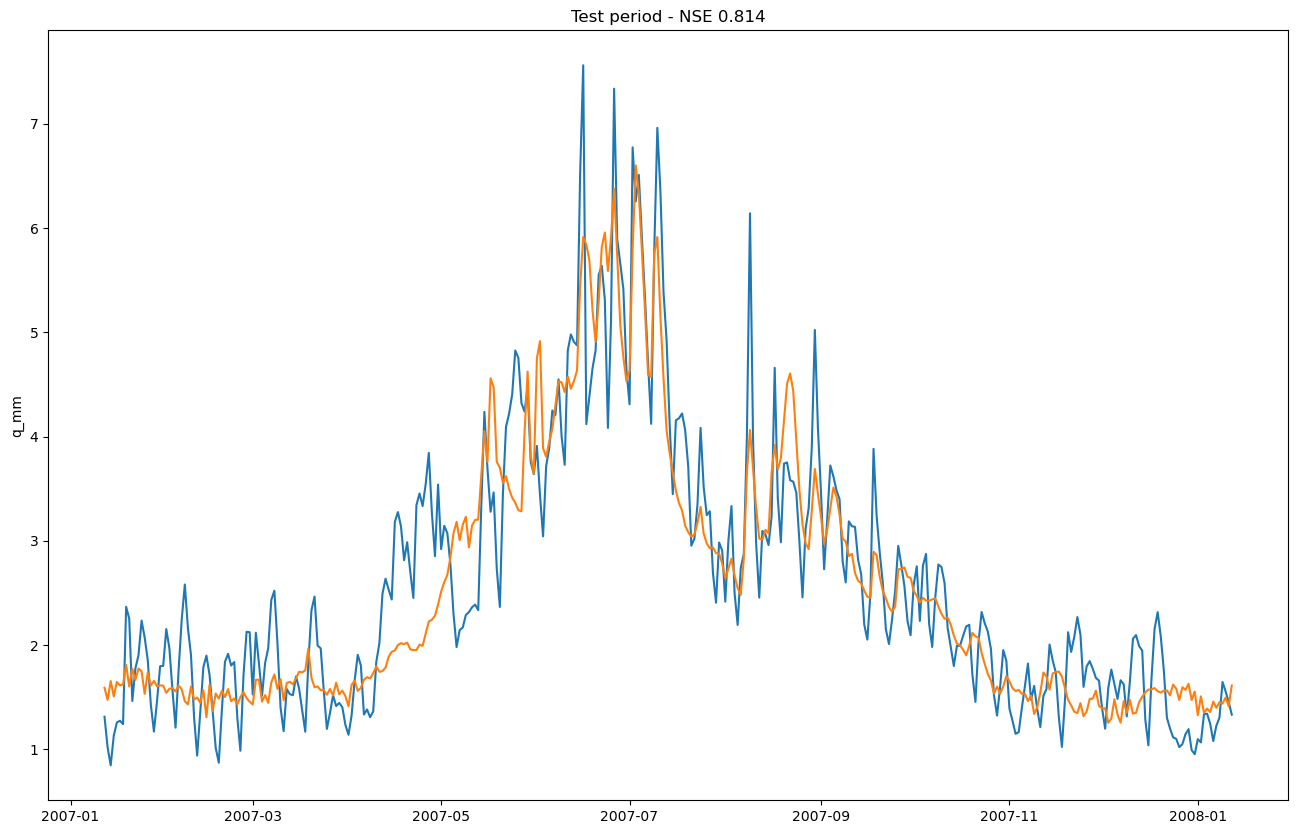

In [16]:
# extract observations and simulations
qobs = results['1']['1D']['xr']['qobs_obs']
qsim = results['1']['1D']['xr']['qobs_sim']

fig, ax = plt.subplots(figsize=(16,10))
ax.plot(qobs['date'], qobs)
ax.plot(qsim['date'], qsim)
ax.set_ylabel("q_mm")
ax.set_title(f"Test period - NSE {results['1']['1D']['NSE']:.3f}")

Next, we are going to compute all metrics that are implemented in the NeuralHydrology package. You will find additional hydrological signatures implemented in `neuralhydrology.evaluation.signatures`.

In [17]:
values = metrics.calculate_all_metrics(qobs.isel(time_step=-1), qsim.isel(time_step=-1))
for key, val in values.items():
    print(f"{key}: {val:.3f}")

NSE: 0.814
MSE: 0.319
RMSE: 0.565
KGE: 0.886
Alpha-NSE: 0.944
Beta-KGE: 0.969
Beta-NSE: -0.061
Pearson-r: 0.905
FHV: -10.430
FMS: 10.876
FLV: 64.327
Peak-Timing: 1.000
Peak-MAPE: 32.596


/home/sngrjohn/anaconda3/envs/neuralhydrology/lib/python3.10/site-packages/neuralhydrology/datautils/utils.py:327: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset_one = to_offset(freq_one)
/home/sngrjohn/anaconda3/envs/neuralhydrology/lib/python3.10/site-packages/neuralhydrology/datautils/utils.py:368: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  factor = pd.to_timedelta(freq_one) / pd.to_timedelta(freq_two)
